# Lab 02: CNN Feature Extraction
## AIM: To understand the process of extracting from images using Convolutional Neural Networks (CNN) and apply CNN models for image classification by analysing the effect of different hyperparameters.

**Decisions Made:**
- **Framework:** PyTorch is used for visualization, along with custom-written functions for convolution.
- **Grayscale Image:** Downloaded a sample medical X-ray image.
- **RGB Image:** Used an RGB image from `skimage.data`.
- **Complexity Element:** 
  1. Implementation of a purely **User-Defined Convolution Function** (from scratch) running alongside library-based convolutions.
  2. Use of **Multiple Filters per Layer** explicitly defined (e.g., Edge Detection, Sharpen, Gaussian Blur) in the user-defined stage.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import skimage.data
import math

# Helper function for visualization
def plot_feature_maps(feature_maps, title="Feature Maps"):
    if isinstance(feature_maps, torch.Tensor):
        feature_maps = feature_maps.squeeze(0).detach().cpu().numpy()
    num_maps = feature_maps.shape[0]
    fig, axes = plt.subplots(1, min(num_maps, 6), figsize=(15, 3))
    if num_maps == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        if i >= num_maps: break
        ax.imshow(feature_maps[i], cmap='gray' if num_maps > 3 or num_maps==1 else 'viridis')
        ax.axis('off')
    plt.suptitle(title)
    plt.show()


## Part 1: Grayscale Medical Image Analysis

Pre-processed Tensor Shape: torch.Size([1, 1, 256, 256])


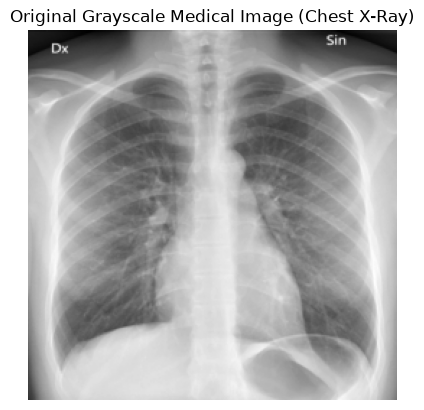

In [2]:
# 1.a Pre-processing
import numpy as np
import urllib.request
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Download a sample grayscale medical image (Chest X-ray)
# Using the original image URL rather than the thumbnail to avoid HTTP 400
url = "https://upload.wikimedia.org/wikipedia/commons/a/a1/Normal_posteroanterior_%28PA%29_chest_radiograph_%28X-ray%29.jpg"
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response:
    with open("chest_xray.jpg", "wb") as f:
        f.write(response.read())

# Load the medical image
gray_image = Image.open("chest_xray.jpg").convert('L')
gray_numpy = np.array(gray_image)

# Resize, Normalize, and convert to Tensor
transform_gray = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]) 
])

gray_tensor = transform_gray(gray_image).unsqueeze(0) # Add batch dimension
print(f"Pre-processed Tensor Shape: {gray_tensor.shape}")

plt.imshow(gray_tensor.squeeze().numpy(), cmap='gray')
plt.title("Original Grayscale Medical Image (Chest X-Ray)")
plt.axis('off')
plt.show()

Applying User-Defined Convolution Function with 3 Filters (Edge, Sharpen, Blur)...


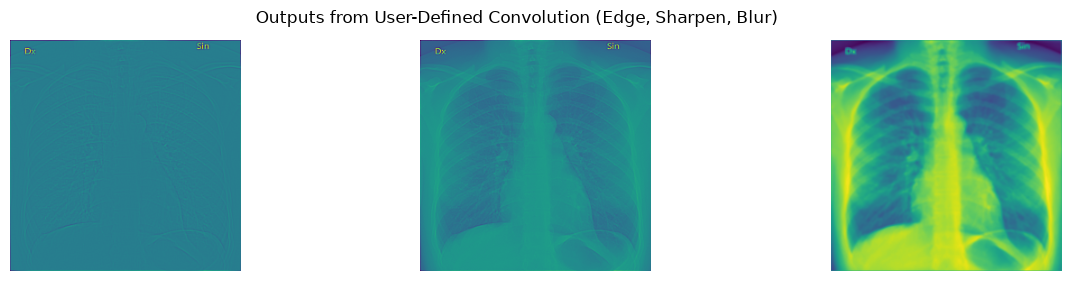

In [3]:
# 1.b Complexity Element: User-Defined Convolution Function with Multiple Filters
def user_defined_conv2d(image, filters, stride=1, padding=1):
    """
    A completely user-defined 2D Convolution function (from scratch).
    image: (1, C, H, W) numpy array or tensor
    filters: (Num_Filters, C, K, K) numpy array or tensor
    """
    if isinstance(image, torch.Tensor):
        image = image.numpy()
    if isinstance(filters, torch.Tensor):
        filters = filters.numpy()
        
    N, C, H, W = image.shape
    F_out, C_filter, K, K2 = filters.shape
    assert C == C_filter, "Image channels must match filter channels"
    assert K == K2, "Filters must be square"
    
    # Calculate output dimensions
    H_out = math.floor((H + 2 * padding - K) / stride) + 1
    W_out = math.floor((W + 2 * padding - K) / stride) + 1
    
    # Pad the image
    padded_image = np.pad(image, ((0, 0), (0, 0), (padding, padding), (padding, padding)), mode='constant')
    
    output = np.zeros((1, F_out, H_out, W_out))
    
    # Perform convolution
    for f in range(F_out):
        for i in range(H_out):
            for j in range(W_out):
                # Extract the region of interest
                region = padded_image[0, :, i*stride : i*stride+K, j*stride : j*stride+K]
                # Element-wise multiplication and sum
                output[0, f, i, j] = np.sum(region * filters[f])
                
    return torch.tensor(output, dtype=torch.float32)

# Define Multiple Manual Filters (Edge, Sharpen, Blur)
filter_edge = [[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]
filter_sharpen = [[0, -1, 0], [-1, 5, -1], [0, -1, 0]]
filter_blur = [[1/9, 1/9, 1/9], [1/9, 1/9, 1/9], [1/9, 1/9, 1/9]]

custom_filters = np.array([filter_edge, filter_sharpen, filter_blur]).reshape(3, 1, 3, 3)

print("Applying User-Defined Convolution Function with 3 Filters (Edge, Sharpen, Blur)...")
# Run user-defined convolution
user_conv_output = user_defined_conv2d(gray_tensor, custom_filters, padding=1)

plot_feature_maps(user_conv_output, title="Outputs from User-Defined Convolution (Edge, Sharpen, Blur)")


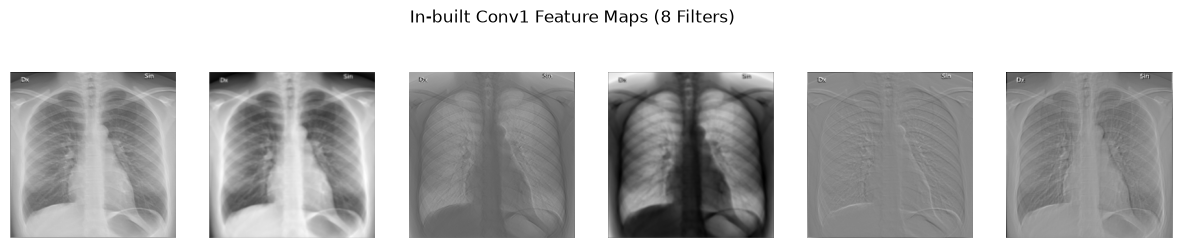

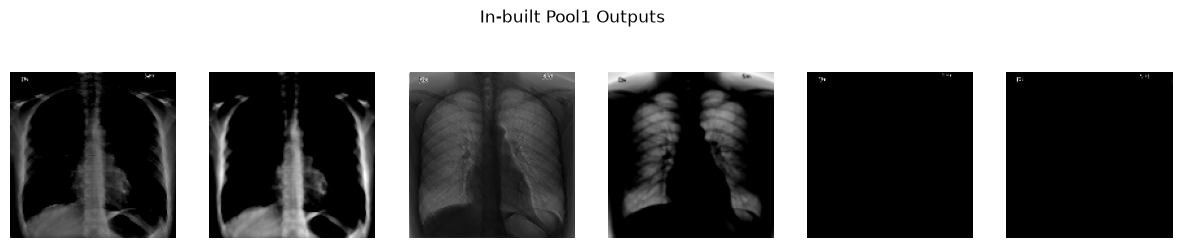

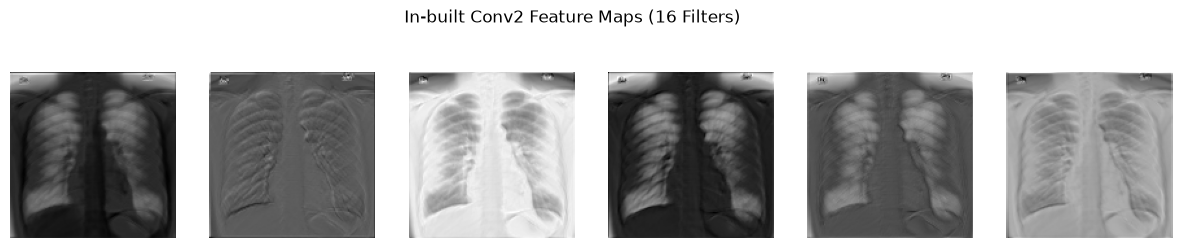

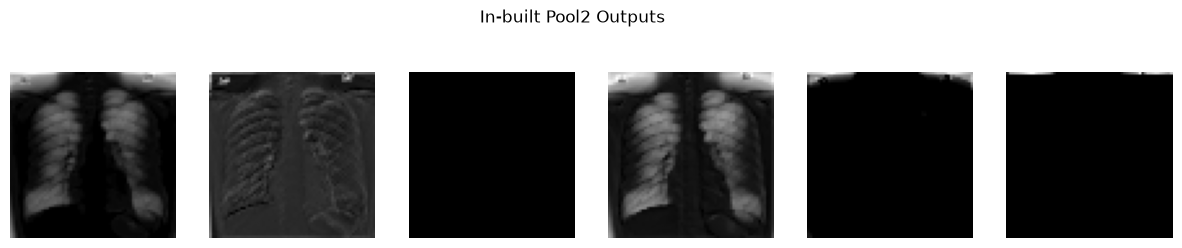

Final Latent Feature Vector Representation Shape: torch.Size([1, 128])
Latent Vector (first 10 values): [ 0.04455031 -0.02012886 -0.01282349 -0.10810479 -0.02176059  0.0428979
 -0.03560599  0.02285823 -0.00475617  0.07545985]


In [4]:
# 1.c CNN Architecture combining In-built functions
class MedicalCNN(nn.Module):
    def __init__(self):
        super(MedicalCNN, self).__init__()
        # In-built Convolution Layer with MULTIPLE filters (8 filters)
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(16 * 64 * 64, 128) 
        
    def forward(self, x):
        features = {}
        
        x = self.conv1(x)
        features['conv1'] = x
        
        x = F.relu(x)
        x = self.pool1(x)
        features['pool1'] = x
        
        x = self.conv2(x)
        features['conv2'] = x
        
        x = F.relu(x)
        x = self.pool2(x)
        features['pool2'] = x
        
        flat = self.flatten(x)
        latent = self.fc(flat)
        features['latent'] = latent
        
        return latent, features

model_med = MedicalCNN()
latent_vec_med, features_med = model_med(gray_tensor)

# Visualize Intermediate Feature Maps
plot_feature_maps(features_med['conv1'], title="In-built Conv1 Feature Maps (8 Filters)")
plot_feature_maps(features_med['pool1'], title="In-built Pool1 Outputs")
plot_feature_maps(features_med['conv2'], title="In-built Conv2 Feature Maps (16 Filters)")
plot_feature_maps(features_med['pool2'], title="In-built Pool2 Outputs")

print(f"Final Latent Feature Vector Representation Shape: {latent_vec_med.shape}")
print(f"Latent Vector (first 10 values): {latent_vec_med[0][:10].detach().numpy()}")


## Part 2: RGB Image Feature Extraction

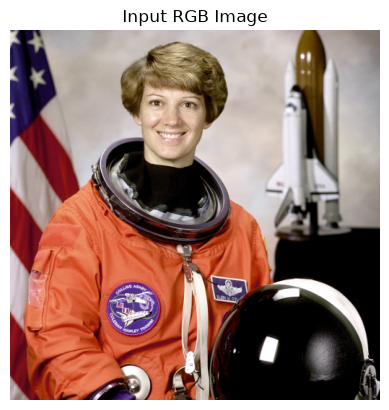

In [5]:
# 2.a Preprocessing RGB Image
rgb_image = skimage.data.astronaut()
rgb_pil = Image.fromarray(rgb_image)

transform_rgb = transforms.Compose([
    transforms.Resize((128, 128)), # Resized slightly smaller for performance
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

rgb_tensor = transform_rgb(rgb_pil).unsqueeze(0)

plt.imshow(rgb_image)
plt.title("Input RGB Image")
plt.axis('off')
plt.show()


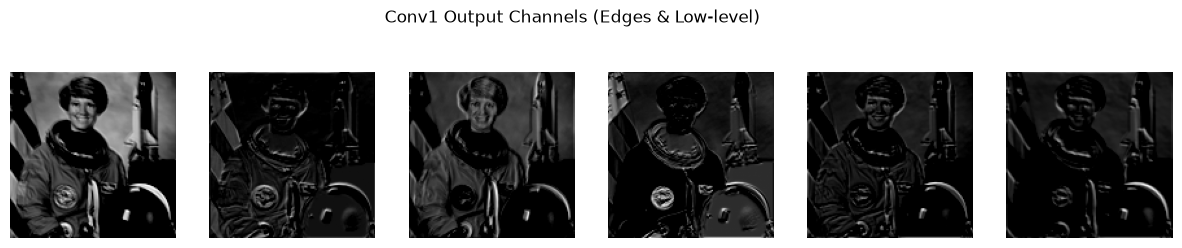

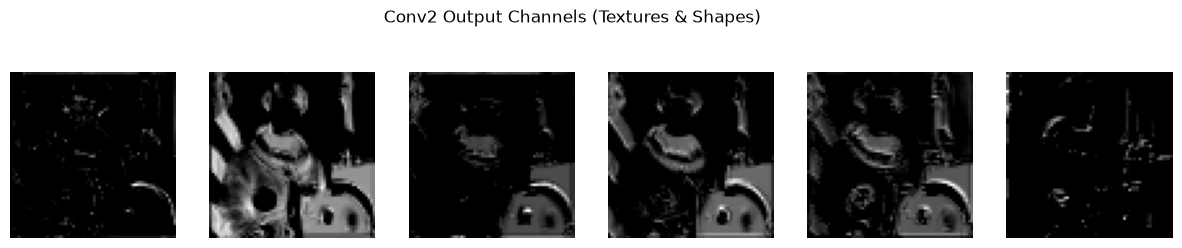

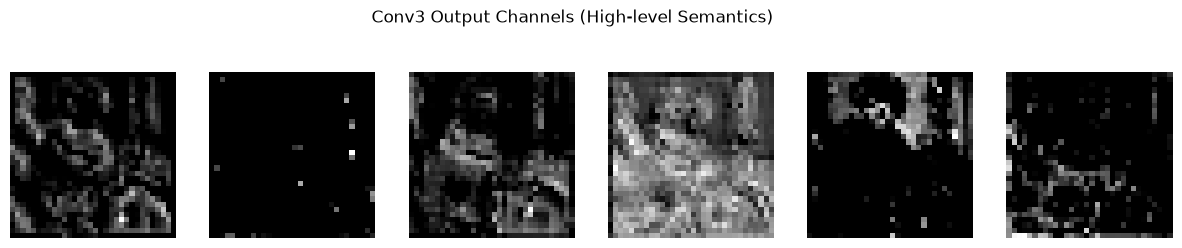

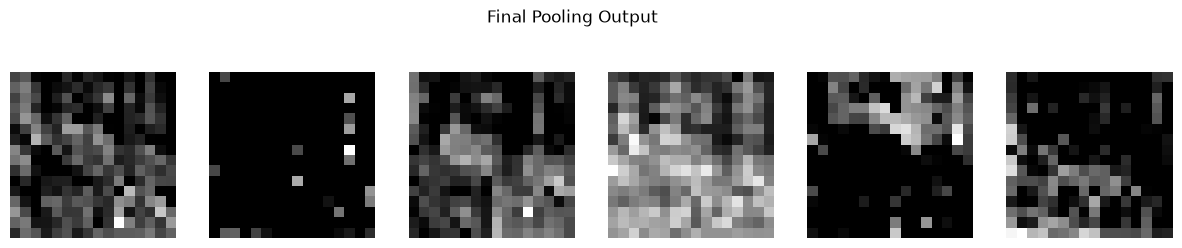

Flattened Representation Shape: torch.Size([1, 16384])
Latent Vector before Classification Layer Shape: torch.Size([1, 512])


In [6]:
# 2.b & 2.c RGB CNN (Edges, Texture, Shape, High-level)
class RGBCNN(nn.Module):
    def __init__(self):
        super(RGBCNN, self).__init__()
        # Layer 1: Edges and Low-level features (16 filters)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Layer 2: Textures and shapes (32 filters)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Layer 3: High-level semantic features (64 filters)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 16 * 16, 512)
        
    def forward(self, x):
        feats = {}
        
        x = F.relu(self.conv1(x))
        feats['conv1_edges'] = x
        x = self.pool1(x)
        feats['pool1'] = x
        
        x = F.relu(self.conv2(x))
        feats['conv2_textures'] = x
        x = self.pool2(x)
        
        x = F.relu(self.conv3(x))
        feats['conv3_semantics'] = x
        x = self.pool3(x)
        feats['pool3'] = x
        
        flat = self.flatten(x)
        feats['flattened'] = flat
        
        latent = F.relu(self.fc1(flat))
        feats['latent'] = latent
        
        return latent, feats

model_rgb = RGBCNN()
latent_rgb, feats_rgb = model_rgb(rgb_tensor)

# Visualize Output Channels
plot_feature_maps(feats_rgb['conv1_edges'], title="Conv1 Output Channels (Edges & Low-level)")
plot_feature_maps(feats_rgb['conv2_textures'], title="Conv2 Output Channels (Textures & Shapes)")
plot_feature_maps(feats_rgb['conv3_semantics'], title="Conv3 Output Channels (High-level Semantics)")
plot_feature_maps(feats_rgb['pool3'], title="Final Pooling Output")

print(f"Flattened Representation Shape: {feats_rgb['flattened'].shape}")
print(f"Latent Vector before Classification Layer Shape: {feats_rgb['latent'].shape}")


## Part B: Apply LENET-5 Architecture on MNIST dataset with Hyperparameter Tuning

We will implement the standard LeNet-5 architecture and test it with different learning rates to check the effect of hyperparameter tuning.

In [7]:
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader

# 1. Load MNIST Dataset
transform = transforms.Compose([
    transforms.Resize((32, 32)), # LeNet-5 expects 32x32 input
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

print(f"Training samples: {len(trainset)}")
print(f"Testing samples: {len(testset)}")


Training samples: 60000
Testing samples: 10000


In [8]:
# 2. Define LeNet-5 Architecture
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.tanh(self.conv1(x))
        x = self.pool1(x)
        
        x = F.tanh(self.conv2(x))
        x = self.pool2(x)
        
        x = F.tanh(self.conv3(x))
        x = x.view(-1, 120)
        
        x = F.tanh(self.fc1(x))
        x = self.fc2(x)
        return x

# Check model structure
model_lenet = LeNet5()
print(model_lenet)


LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (pool1): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=120, out_features=84, bias=True)
  (fc2): Linear(in_features=84, out_features=10, bias=True)
)


In [ ]:
# 3. Hyperparameter Tuning and Training
# We will test 3 different learning rates as our complexity element.
learning_rates = [0.001, 0.01, 0.1]
results = {}

criterion = nn.CrossEntropyLoss()

for lr in learning_rates:
    print(f"\n--- Training with Learning Rate: {lr} ---")
    model = LeNet5()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    
    # Train for a few epochs for demonstration
    epochs = 2
    for epoch in range(epochs):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader):.4f}")
    
    # Evaluate
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            inputs, labels = data
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f"Accuracy for LR={lr}: {accuracy:.2f}%")
    results[lr] = accuracy

# 4. Plot Hyperparameter Tuning Results
import matplotlib.pyplot as plt

lrs = [str(lr) for lr in results.keys()]
accs = list(results.values())

plt.figure(figsize=(8, 5))
plt.bar(lrs, accs, color=['skyblue', 'salmon', 'lightgreen'])
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy (%)')
plt.title('LeNet-5 Accuracy vs Learning Rate on MNIST')
plt.ylim(0, 100)
for i, v in enumerate(accs):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center')
plt.show()



--- Training with Learning Rate: 0.001 ---
Epoch 1, Loss: 1.3339
Epoch 2, Loss: 0.4440
Accuracy for LR=0.001: 90.39%

--- Training with Learning Rate: 0.01 ---


In [ ]:
print("Hello World")